# Customer Intelligence System — Step 5: Explanations (SHAP)
**Question:** *why* is this customer flagged?

SHAP splits each customer's churn score into contributions from each feature:
`churn score = average score + Σ (feature contributions)`
e.g. *"Last order 235 days ago → +18 pts, 40 orders in total → −9 pts"*.

In [1]:
# 5.1 Setup: load the final model + today's scored customers
import sys, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib, shap

sys.path.insert(0, str(Path("../src").resolve()))
from explain import top_reasons

PROC, MODELS = Path("../data/processed"), Path("../models")
bundle   = joblib.load(MODELS / "churn_model.joblib")
pipe, FEATS = bundle["model"], bundle["features"]
current  = pd.read_parquet(PROC / "customers_scored.parquet")
active   = current[current["risk_band"] != "Already lost"].copy()
print("model:", bundle["family"], "| customers to explain:", len(active))

model: Random Forest | customers to explain: 4261


In [2]:
# 5.2 Compute SHAP values
# The pipeline = imputer (+ 'was missing' indicator columns) -> Random Forest.
# SHAP explains the forest on the imputed matrix; indicator effects are then folded back
# into their original feature so every contribution maps to one readable feature.
prep, forest = pipe[:-1], pipe[-1]
X_imp = prep.transform(active[FEATS])
names = list(prep.get_feature_names_out(FEATS))

explainer = shap.TreeExplainer(forest)
parts, t0 = [], time.time()
for start in range(0, len(X_imp), 500):                 # batches so you can see progress
    sv = explainer.shap_values(X_imp[start:start + 500])
    parts.append(sv[:, :, 1] if np.ndim(sv) == 3 else sv[1])   # class 1 = churn
    print(f"  {min(start + 500, len(X_imp))}/{len(X_imp)} done ({time.time() - t0:.0f}s)")
raw = pd.DataFrame(np.vstack(parts), columns=names, index=active.index)

shap_df = pd.DataFrame(index=active.index)
for f in FEATS:
    shap_df[f] = raw[f] + (raw[f"missingindicator_{f}"] if f"missingindicator_{f}" in raw else 0)

base = float(np.ravel(explainer.expected_value)[-1])
check = (base + shap_df.sum(axis=1) - active["churn_prob"]).abs().max()
print(f"average score (base): {base:.3f} | max additivity error: {check:.6f}  (should be ~0)")

  500/4261 done (26s)
  1000/4261 done (56s)
  1500/4261 done (86s)
  2000/4261 done (116s)
  2500/4261 done (140s)
  3000/4261 done (153s)
  3500/4261 done (173s)
  4000/4261 done (195s)
  4261/4261 done (202s)
average score (base): 0.582 | max additivity error: 0.000000  (should be ~0)


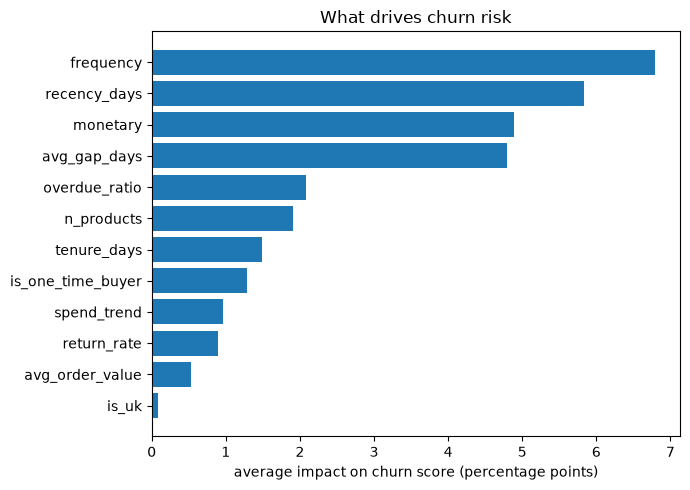

In [3]:
# 5.3 Global view: which features drive churn risk overall?
importance = shap_df.abs().mean().sort_values()
plt.figure(figsize=(7, 5))
plt.barh(importance.index, importance.values * 100)
plt.xlabel("average impact on churn score (percentage points)"); plt.title("What drives churn risk")
plt.tight_layout(); plt.show()

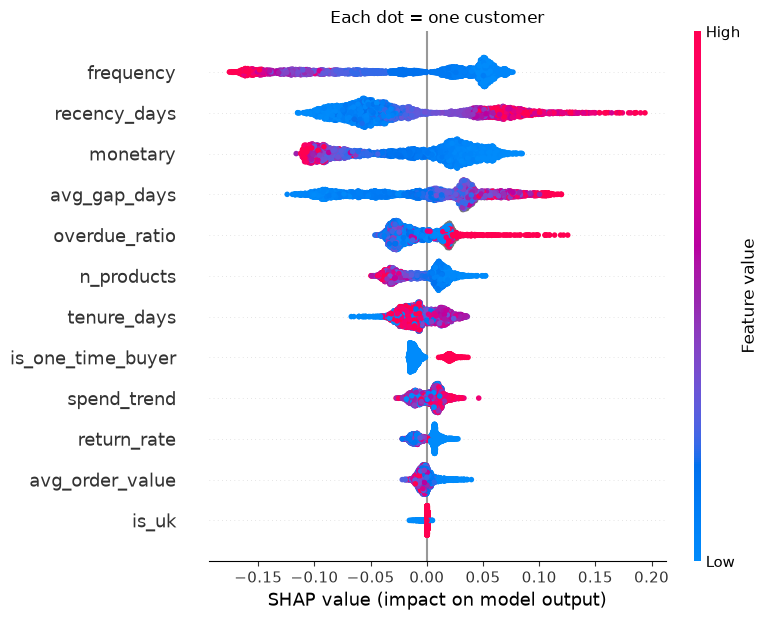

In [4]:
# 5.4 Direction: high vs low feature values (red = high value, blue = low)
shap.summary_plot(shap_df.values, active[FEATS], feature_names=FEATS, show=False)
plt.title("Each dot = one customer"); plt.tight_layout(); plt.show()

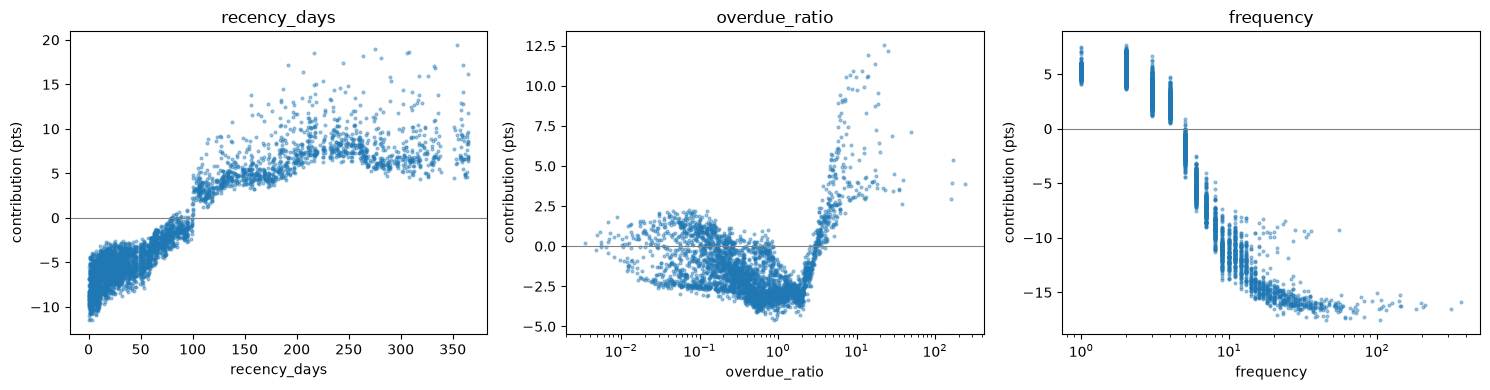

In [5]:
# 5.5 Where does risk jump? Feature value vs its contribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, ["recency_days", "overdue_ratio", "frequency"]):
    ax.scatter(active[f], shap_df[f] * 100, s=4, alpha=0.4)
    ax.axhline(0, color="grey", lw=0.8); ax.set_xlabel(f); ax.set_ylabel("contribution (pts)")
    if f in ("overdue_ratio", "frequency"): ax.set_xscale("log")
    ax.set_title(f)
plt.tight_layout(); plt.show()

In [6]:
# 5.6 Plain-English top-3 reasons for every customer
reasons = {cid: top_reasons(shap_df.loc[cid], active.loc[cid]) for cid in active.index}
for i in range(3):
    active[f"reason_{i + 1}"] = [reasons[cid][i] for cid in active.index]

def explain_customer(cid):
    r = active.loc[cid]
    print(f"Customer {cid} | {r['segment']} | risk band: {r['risk_band']} | churn score {r['churn_prob']:.0%}")
    for i in range(3): print("   -", r[f"reason_{i + 1}"])
    top = shap_df.loc[cid].reindex(shap_df.loc[cid].abs().sort_values().index)
    plt.figure(figsize=(7, 4))
    plt.barh(top.index, top.values * 100, color=["tab:red" if v > 0 else "tab:blue" for v in top.values])
    plt.axvline(0, color="grey", lw=0.8)
    plt.title(f"Customer {cid}: from {base:.0%} average to {r['churn_prob']:.0%}")
    plt.xlabel("contribution (pts): red raises risk, blue lowers it"); plt.tight_layout(); plt.show()

Customer 12590 | Loyal Regulars | risk band: High | churn score 81%
   - Last order 211 days ago -> raises risk (+10 pts)
   - 1 order in total -> raises risk (+7 pts)
   - £9,341 lifetime spend -> lowers risk (-6 pts)


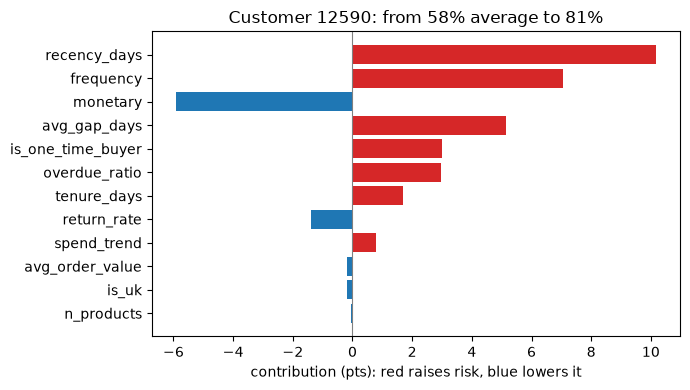

In [7]:
# 5.7 Example: the highest value-at-risk customer in the High band (top of the 'who to call' list)
call_list = active[active["risk_band"] == "High"].sort_values("value_at_risk", ascending=False)
explain_customer(call_list.index[0])

Customer 16779 | Champions | risk band: Low | churn score 1%
   - 53 orders in total -> lowers risk (-16 pts)
   - £32,706 lifetime spend -> lowers risk (-11 pts)
   - Usually orders every 15 days -> lowers risk (-9 pts)


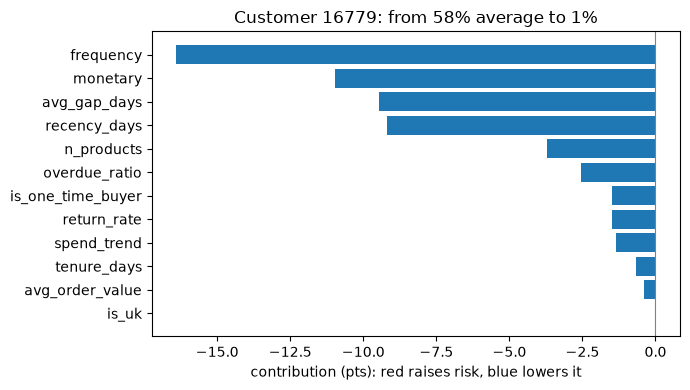

In [8]:
# 5.8 Contrast: a safe Champion (lowest risk)
safe = active[active["segment"] == "Champions"].sort_values("churn_prob")
explain_customer(safe.index[0] if len(safe) else active["churn_prob"].idxmin())

In [9]:
# 5.9 Save: reasons + per-feature contributions for the app
out = current.join(active[["reason_1", "reason_2", "reason_3"]]).join(shap_df.add_prefix("shap_"))
out.to_parquet(PROC / "customers_explained.parquet")
joblib.dump({"base_value": base}, MODELS / "shap_base.joblib")
print("saved customers_explained.parquet", out.shape)
out.loc[call_list.index[:5], ["segment", "churn_prob", "value_at_risk", "reason_1", "reason_2"]]

saved customers_explained.parquet (5839, 48)


,segment,churn_prob,value_at_risk,reason_1,reason_2
Customer ID,,,,,
12590,Loyal Regulars,0.813751,7601.463920,Last order 211 days ago -> raises risk (+10 pts),1 order in total -> raises risk (+7 pts)
12688,Loyal Regulars,0.740687,3609.968923,1 order in total -> raises risk (+7 pts),"£4,874 lifetime spend -> lowers risk (-6 pts)"
13135,Loyal Regulars,0.765517,2370.040839,Last order 196 days ago -> raises risk (+9 pts),"£3,371 lifetime spend -> lowers risk (-7 pts)"
16698,Lapsed Regulars,0.784835,1568.099640,Last order 226 days ago -> raises risk (+12 pts),Silent for 8.4x their usual gap -> raises risk...
12501,Lapsed Regulars,0.779718,1555.841549,Last order 336 days ago -> raises risk (+8 pts),1 order in total -> raises risk (+6 pts)
